# Simulating a PEMFC polarization curve with the transient model

This notebook demonstrates how to use `TransientCellModel` (wrapped in `BaseModel`) to
simulate a polarization curve experiment. The approach mimics a galvanostatic step
protocol: current density is held constant for a short period at each operating point,
allowing the internal state (water content, temperature, gas concentrations, liquid
saturation) to reach near-steady state before the cell voltage is recorded.

**Model components used**
- `Cell` / `CellSide` — geometry and material arrays
- `PtCCatalystLayer` — Pt/C catalyst layer with explicit ionomer film geometry
- `PorousLayer` — GDL
- `FlowChannel` — gas channels
- `Nafion_N212` — 50 µm Nafion membrane from the materials database
- `PFSAModel` / `PtCCatalystLayerModel` / `VoltageModel` — stateless strategy objects
- `TransientCellModel` — ODE engine that assembles and integrates the state equations
- `BaseModel` — composes submodels into a single ODE whose `rates_of_change(t, x)`
  can be passed directly to `scipy.integrate.solve_ivp`

In [110]:
import numpy as np
import cantera as ct
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

import marapendi as mrpd

## 1 — Building the cell

We assemble a single-cell PEMFC using the component API.  Each side (`CellSide`)
carries a catalyst layer, a GDL, and a flow channel.  **Physics models live on
`CellBaseModel`**, not on `Cell` — the cell dataclass holds geometry and materials only.

In [ ]:
# ── Catalyst layers ────────────────────────────────────────────────────────
# ORR kinetics for PEM — Tafel slope b = RT / (n * α * F)
#   n=2, α=0.5  →  b ≈ 68 mV/decade at 70 °C (standard ORR convention in PFSA)
#   reference_activity in the same units as p_O2 (Pa); standard = 1e5 Pa
orr_kinetics = mrpd.ElectrochemicalReaction(
    reference_exchange_current_density=2.54e-4,  # A/m²_Pt
    activation_energy=67e6,
    reaction_order=0.54,
    reference_activity=1e5,                       # Pa  (standard pressure)
    reference_temperature=353.15,
    number_of_electrons=2,
    charge_transfer_coeff=0.5,                    # → b ≈ 68 mV/dec at 70 °C
)

ca_cl = mrpd.PtCCatalystLayer(
    thickness=10e-6,
    bulk_density=1000.,
    bulk_specific_heat_capacity=710.,
    bulk_thermal_conductivity=0.25,
    L_Pt=0.3e-2,       # kg/m²
    wt_Pt=0.4,
    ic_ratio=1.,
    ecsa=45e3,          # m²/kg_Pt
    ionomer=mrpd.Nafion_N21X,
    r_C=25e-9,          # carbon agglomerate radius
    K_abs=1e-12,
    theta_contact=95,
    d_p=50e-9,          # 50 nm primary CL pores → Knudsen diffusion active
    reaction=orr_kinetics,
)

an_cl = mrpd.PtCCatalystLayer(
    thickness=10e-6,
    bulk_density=1000.,
    bulk_specific_heat_capacity=710.,
    bulk_thermal_conductivity=0.25,
    L_Pt=0.3e-2,
    wt_Pt=0.4,
    ic_ratio=1.,
    ecsa=45e3,
    ionomer=mrpd.Nafion_N21X,
    r_C=25e-9,
    K_abs=1e-12,
    theta_contact=95,
    d_p=50e-9,
    reaction=orr_kinetics,
)

# ── GDLs — one instance per side ─────────────────────────────────────────
# Each side MUST use its own PorousLayer instance.
gdl_an = mrpd.PorousLayer(
    thickness=160e-6,
    eps_p=0.72,
    bulk_density=440.,
    bulk_specific_heat_capacity=710.,
    bulk_thermal_conductivity=1.24,
    K_abs=1e-13,
    theta_contact=115.,
    tort=3,
)
gdl_ca = mrpd.PorousLayer(
    thickness=160e-6,
    eps_p=0.72,
    bulk_density=440.,
    bulk_specific_heat_capacity=710.,
    bulk_thermal_conductivity=1.24,
    K_abs=1e-13,
    theta_contact=115.,
    tort=3,
)

# ── Cell assembly — geometry and materials only, no physics models ────────
base_cell = mrpd.Cell(
    area=25e-4,                   # m²
    electrical_resistance=30e-7,  # Ω·m²
    thermal_resistance=2e-4,      # m²·K/W
    ca=mrpd.CellSide(
        cl=ca_cl,
        gdl=gdl_ca,
        ch=mrpd.FlowChannel(height=1e-3, bulk_thermal_conductivity=100.),
        has_mpl=False,
    ),
    an=mrpd.CellSide(
        cl=an_cl,
        gdl=gdl_an,
        ch=mrpd.FlowChannel(height=1e-3, bulk_thermal_conductivity=100.),
        has_mpl=False,
    ),
    memb=mrpd.Nafion_N212,
)

model = mrpd.TransientCellModel(cell=base_cell)

print(f"Layers ({model.n_layers}):")
for layer in base_cell.layers:
    print(f"  [{layer.ix}] {layer.name}  thickness = {layer.thickness*1e6:.0f} µm")

## 2 — Building the `CellBaseModel` and initial conditions

`CellBaseModel` owns the five physics strategy objects as named fields and
wires the `TransientCellModel` into `submodels` automatically.
Its `initial_state(**kwargs)` accepts flat keyword arguments, and
`postprocess(y_flat)` unpacks any state vector into a fully-populated `CellState`.

The state vector has shape `(n_layers × n_variables)`:

| Index | Symbol | Unit    | Description                |
|-------|--------|---------|----------------------------|
| 0     | λ      | mol/mol | Ionomer water content      |
| 1     | T      | K       | Temperature                |
| 2     | c_O₂   | kmol/m³ | O₂ concentration           |
| 3     | c_N₂   | kmol/m³ | N₂ concentration           |
| 4     | c_H₂   | kmol/m³ | H₂ concentration           |
| 5     | c_H₂O  | kmol/m³ | Water vapour concentration |
| 6     | s      | —       | Liquid water saturation    |

In [112]:
T_OP = 343.15   # K  (80 °C)
P_OP = 1.2e5    # Pa (1.5 bara)
RH   = 0.9      # relative humidity at both inlets

# current_density is a named field on TransientCellModel — no mutable
# container or manual input_fns dict needed.  CellBaseModel registers
# get_inputs automatically and injects itself as base_model.
base = mrpd.CellBaseModel(
    transient_transport_model=mrpd.TransientCellModel(
        cell=base_cell,
        current_density=0.,   # updated each step in the loop below
    ),
    memb_model=mrpd.PFSAModel(),
    cl_model=mrpd.PtCCatalystLayerModel(),
    gas_diffusion_model=mrpd.PorousGasResistanceModel(),
    darcy_transport_model=mrpd.DarcyTransportModel(),
    voltage_model=mrpd.VoltageModel(),
)

model = base.transient_transport_model   # shorthand for post-processing

y0 = base.initial_state(
    cell_temperature=T_OP,
    cell_pressure=P_OP,
    ca_rh=RH,
    an_rh=RH,
    ca_dry_o2=0.21,   # cathode: air
    an_dry_h2=1.0,    # anode:   pure H₂
)
print(f"State vector length: {len(y0)}  ({model.n_layers} layers × {model.n_variables} variables)")

State vector length: 49  (7 layers × 7 variables)


## 3 — Simulating a step-current polarization curve

At each step the cell is integrated for `T_STEP` seconds with BDF (stiff solver).
The final state of one step becomes the initial state of the next, so the cell
progressively hydrates and warms up — exactly as in a real galvanostatic sweep.

`model.current_density` is updated directly before each step; no mutable container
or manual `input_fns` dict is needed.  `base.solve(...)` wraps `solve_ivp` with
BDF as the default.  `base.postprocess(...)` unpacks the solution into a `CellState`.

## 4 — Simulating a step-current polarization curve

We sweep from low to high current density.  At each step the cell is
integrated for `T_STEP` seconds with BDF (stiff solver).  The final state
of one step becomes the initial state of the next, so the cell progressively
hydrates and warms up — exactly as in a real galvanostatic experiment.

`base.rates_of_change` is passed directly as `fun` — no lambda needed.

In [ ]:
CURRENT_DENSITIES = np.array([200, 500, 1000, 2000, 4000, 7000, 10000, 15000, 20000, 25000, 30000])  # A/m²
T_STEP = 100.0   # s — integration time per current step

results = []   # list of CellState objects, one per step
y_current = y0.copy()

for k, i_density in enumerate(CURRENT_DENSITIES):
    model.current_density = float(i_density)   # update named field directly

    sol = base.solve(y_current, t_span=(0., T_STEP), max_step=10.)
    y_current = sol.y[:, -1]
    state = base.postprocess(y_current[:, np.newaxis])
    results.append(state)
    print(f"i = {i_density/1e4:5.2f} A/cm²   V_cell = {state.V_cell.item():.3f} V")

## 5 — Polarization and power-density curves

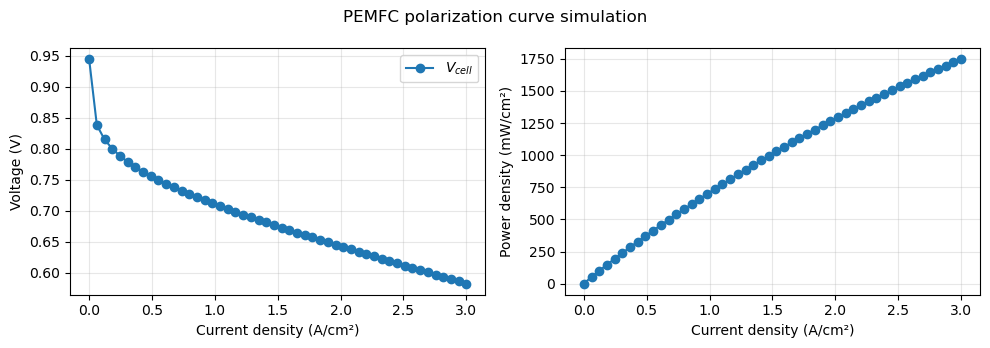

In [114]:
i_Acm2   = CURRENT_DENSITIES / 1e4          # A/cm²
V_cell   = np.array([s.V_cell.item()   for s in results])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
fig.suptitle('PEMFC polarization curve simulation', fontsize=12)

ax = axes[0]
ax.plot(i_Acm2, V_cell,   'C0-o', label='$V_{cell}$')
ax.set_xlabel('Current density (A/cm²)')
ax.set_ylabel('Voltage (V)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(i_Acm2, i_Acm2 * V_cell * 1e3, 'C0-o')
ax.set_xlabel('Current density (A/cm²)')
ax.set_ylabel('Power density (mW/cm²)')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 6 — Overpotential breakdown

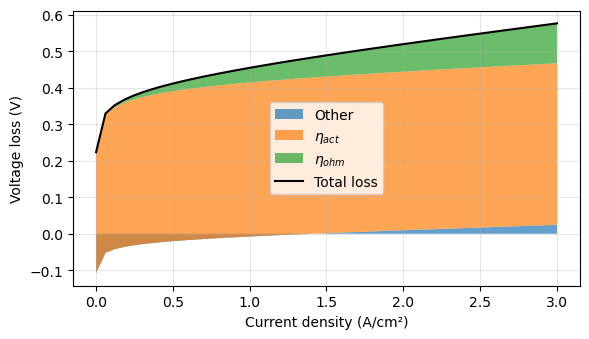

In [115]:
fig, ax = plt.subplots(figsize=(6, 3.5))

ax.stackplot(
    i_Acm2,
    E_rev - V_cell - eta_ohm - eta_act,   # remainder (crossover etc.)
    eta_act * np.ones_like(i_Acm2),
    eta_ohm * np.ones_like(i_Acm2),
    labels=['Other', '$\\eta_{act}$', '$\\eta_{ohm}$'],
    alpha=0.7,
)
ax.plot(i_Acm2, E_rev - V_cell, 'k-', label='Total loss')
ax.set_xlabel('Current density (A/cm²)')
ax.set_ylabel('Voltage loss (V)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 6 — Internal state diagnostics

Run one longer step at 1 A/cm² and observe how the internal variables evolve over time.
A dedicated `CellBaseModel` is created with constant `current_density` — no loop needed.
`base_diag.postprocess(sol.y)` vectorises over all time steps at once.

In [116]:
I_DIAG = 10000.  # A/m² — 1 A/cm²
t_eval = np.linspace(0, 200, 201)

base_diag = mrpd.CellBaseModel(
    transient_transport_model=mrpd.TransientCellModel(
        cell=base_cell,
        current_density=I_DIAG,
    ),
    memb_model=mrpd.PFSAModel(),
    cl_model=mrpd.PtCCatalystLayerModel(),
    gas_diffusion_model=mrpd.PorousGasResistanceModel(),
    darcy_transport_model=mrpd.DarcyTransportModel(),
    voltage_model=mrpd.VoltageModel(),
)

sol_diag = base_diag.solve(y0, t_span=(t_eval[0], t_eval[-1]),
                            max_step=2., t_eval=t_eval)

# current_density is constant so no explicit i_density argument needed
state_diag = base_diag.postprocess(sol_diag.y)

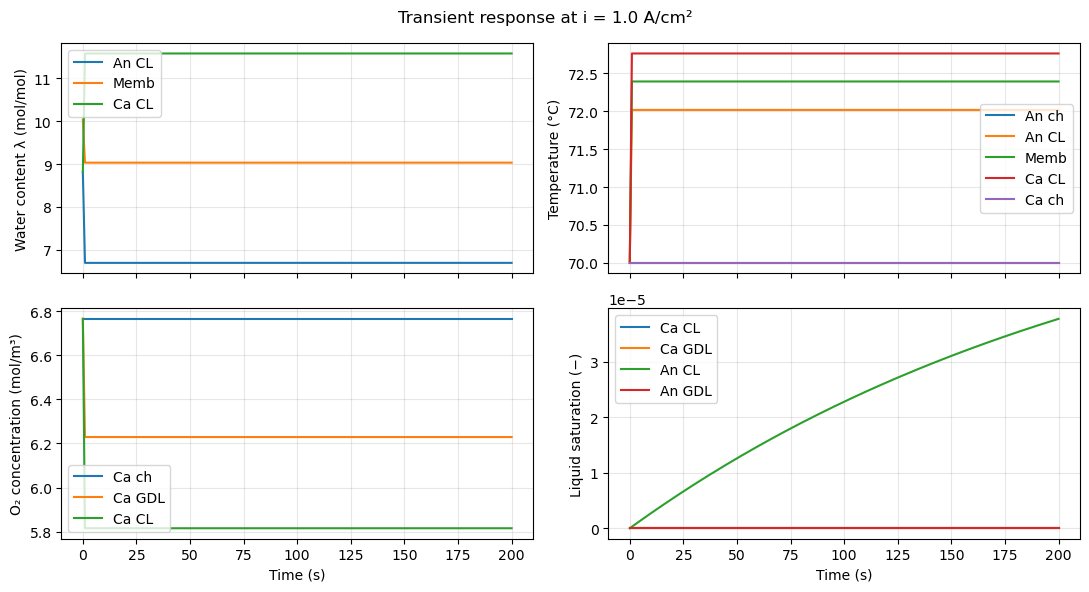

In [117]:
t = sol_diag.t
c = model.cell

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
fig.suptitle(f'Transient response at i = {I_DIAG/1e4:.1f} A/cm²')

# --- Water content λ ---
ax = axes[0, 0]
for ix, label in [(c.an.cl.ix, 'An CL'), (c.memb.ix, 'Memb'), (c.ca.cl.ix, 'Ca CL')]:
    ax.plot(t, state_diag.lmbd[ix, :], label=label)
ax.set_ylabel('Water content λ (mol/mol)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Temperature ---
ax = axes[0, 1]
for ix, label in [(c.an.ch.ix, 'An ch'), (c.an.cl.ix, 'An CL'),
                   (c.memb.ix, 'Memb'), (c.ca.cl.ix, 'Ca CL'), (c.ca.ch.ix, 'Ca ch')]:
    ax.plot(t, state_diag.T[ix, :] - 273.15, label=label)
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- O₂ concentration at cathode layers ---
ax = axes[1, 0]
for ix, label in [(c.ca.ch.ix, 'Ca ch'), (c.ca.gdl.ix, 'Ca GDL'), (c.ca.cl.ix, 'Ca CL')]:
    ax.plot(t, state_diag.cg_k[ix, 0, :] * 1e3, label=label)
ax.set_xlabel('Time (s)')
ax.set_ylabel('O₂ concentration (mol/m³)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Liquid saturation ---
ax = axes[1, 1]
for ix, label in [(c.ca.cl.ix, 'Ca CL'), (c.ca.gdl.ix, 'Ca GDL'),
                   (c.an.cl.ix, 'An CL'), (c.an.gdl.ix, 'An GDL')]:
    ax.plot(t, state_diag.s[ix, :], label=label)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Liquid saturation (−)')
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 7 — Cell voltage over time during a step

Plot `V_cell` versus time for the diagnostic run to visualise how quickly
the cell settles after the current is applied.

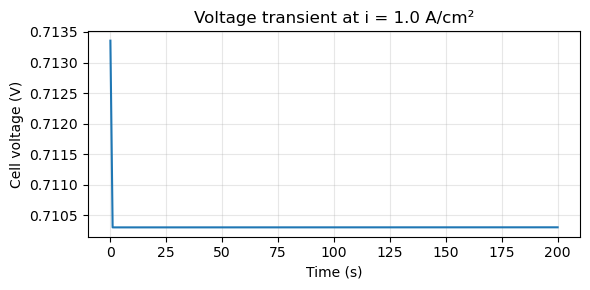

In [118]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t, state_diag.V_cell, 'C0-')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cell voltage (V)')
ax.set_title(f'Voltage transient at i = {I_DIAG/1e4:.1f} A/cm²')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()